In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [3]:
columns = ['Date','Time','Season','Year','HomeTeam','AwayTeam','FTHG','FTAG','FTR','HTHG','HTAG','HTR','Referee','HS','AS','HST','AST', 'HF','AF','HC','AC','HY','AY','HR','AR',
            'B365H','B365D','B365A']
df = pd.read_csv('/home/milan/ml_projects/pl_ml/artifacts/train.csv',usecols=columns)

In [4]:
df['Season']  = df['Season'].astype(str)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [5]:
df.head()

,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AC,HY,AY,HR,AR,B365H,B365D,B365A,Season,Year
0,2025-08-15,20:00,Liverpool,Bournemouth,4,2,H,1,0,H,...,7,1,2,0,0,1.30,6.00,8.50,2526,2025
1,2025-08-16,12:30,Aston Villa,Newcastle,0,0,D,0,0,D,...,6,1,1,1,0,2.25,3.50,2.90,2526,2025
2,2025-08-16,15:00,Brighton,Fulham,1,1,D,0,0,D,...,3,3,3,0,0,1.91,3.60,4.00,2526,2025
3,2025-08-16,15:00,Sunderland,West Ham,3,0,H,0,0,D,...,7,0,1,0,0,3.25,3.40,2.25,2526,2025
4,2025-08-16,15:00,Tottenham,Burnley,3,0,H,1,0,H,...,5,0,0,0,0,1.38,4.75,8.50,2526,2025


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 566 entries, 0 to 565
Data columns (total 28 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      566 non-null    datetime64[us]
 1   Time      566 non-null    str           
 2   HomeTeam  566 non-null    str           
 3   AwayTeam  566 non-null    str           
 4   FTHG      566 non-null    int64         
 5   FTAG      566 non-null    int64         
 6   FTR       566 non-null    str           
 7   HTHG      566 non-null    int64         
 8   HTAG      566 non-null    int64         
 9   HTR       566 non-null    str           
 10  Referee   566 non-null    str           
 11  HS        566 non-null    int64         
 12  AS        566 non-null    int64         
 13  HST       566 non-null    int64         
 14  AST       566 non-null    int64         
 15  HF        566 non-null    int64         
 16  AF        566 non-null    int64         
 17  HC        566 non-null    i

In [7]:
df.describe()

,Date,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,...,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,Year
count,566,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,...,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000
mean,2025-04-13 20:54:16.537102,1.537102,1.358657,0.743816,0.567138,13.648410,11.761484,4.713781,4.121908,10.722615,...,5.378092,4.757951,1.805654,2.121908,0.063604,0.060071,2.702792,4.219170,4.172261,2024.667845
min,2024-08-16 00:00:00,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.080000,3.000000,1.200000,2024.000000
25%,2024-12-07 00:00:00,1.000000,1.000000,0.000000,0.000000,10.000000,8.000000,3.000000,3.000000,8.000000,...,3.000000,3.000000,1.000000,1.000000,0.000000,0.000000,1.620000,3.500000,2.200000,2024.000000
50%,2025-03-15 00:00:00,1.000000,1.000000,1.000000,0.000000,13.000000,11.000000,4.500000,4.000000,10.000000,...,5.000000,4.000000,2.000000,2.000000,0.000000,0.000000,2.225000,3.800000,3.200000,2025.000000
75%,2025-09-20 00:00:00,2.000000,2.000000,1.000000,1.000000,17.000000,15.000000,6.000000,5.000000,13.000000,...,7.000000,6.000000,3.000000,3.000000,0.000000,0.000000,3.200000,4.500000,5.000000,2025.000000
max,2025-12-30 00:00:00,7.000000,6.000000,4.000000,5.000000,36.000000,37.000000,16.000000,13.000000,21.000000,...,17.000000,18.000000,7.000000,8.000000,2.000000,1.000000,11.000000,12.000000,23.000000,2025.000000
std,NaN,1.252764,1.167550,0.843353,0.799279,5.375301,5.217533,2.412223,2.284456,3.548264,...,3.031133,2.928601,1.363638,1.393149,0.258348,0.237828,1.610607,1.175784,3.045945,0.471403


In [8]:
df.describe(include='object')

/tmp/ipykernel_4627/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Time,HomeTeam,AwayTeam,FTR,HTR,Referee,Season
count,566,566,566,566,566,566,566
unique,17,23,23,3,3,29,2
top,15:00,Chelsea,Bournemouth,H,H,A Taylor,2425
freq,200,29,29,242,218,45,380


In [9]:
df.isnull().sum()

Date        0
Time        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
HTHG        0
HTAG        0
HTR         0
Referee     0
HS          0
AS          0
HST         0
AST         0
HF          0
AF          0
HC          0
AC          0
HY          0
AY          0
HR          0
AR          0
B365H       0
B365D       0
B365A       0
Season      0
Year        0
dtype: int64

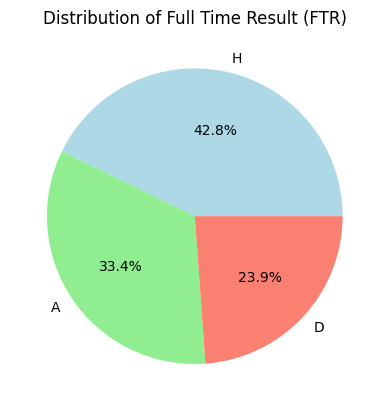

In [10]:
df['FTR'].value_counts().plot(kind='pie',autopct='%1.1f%%', colors=['lightblue', 'lightgreen', 'salmon'])
plt.title('Distribution of Full Time Result (FTR)')
plt.show()

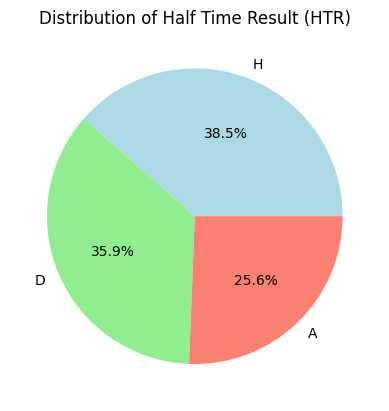

In [11]:
df['HTR'].value_counts().plot(kind='pie',autopct='%1.1f%%', colors=['lightblue', 'lightgreen', 'salmon'])
plt.title('Distribution of Half Time Result (HTR)')
plt.show()

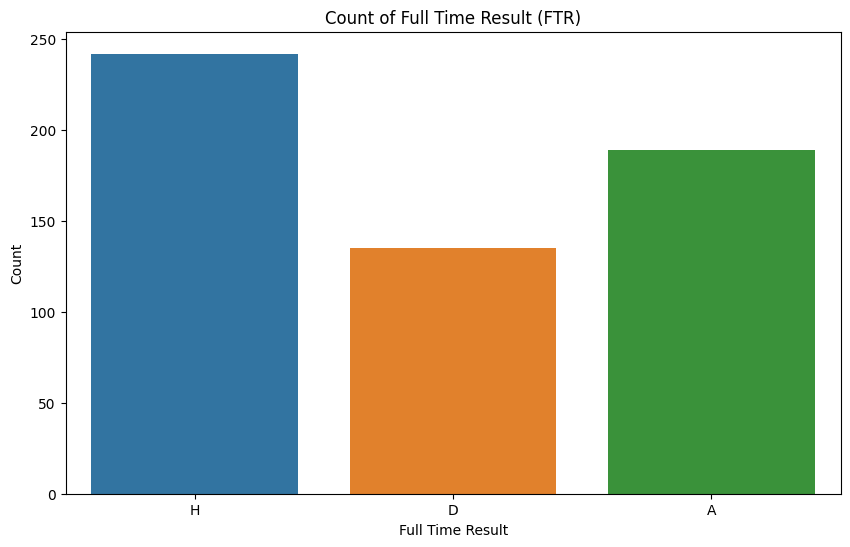

In [12]:
plt.figure(figsize=(10,6))
sns.countplot(x='FTR', data=df, hue = 'FTR',legend=False)
plt.title('Count of Full Time Result (FTR)')
plt.xlabel('Full Time Result')
plt.ylabel('Count')
plt.show()


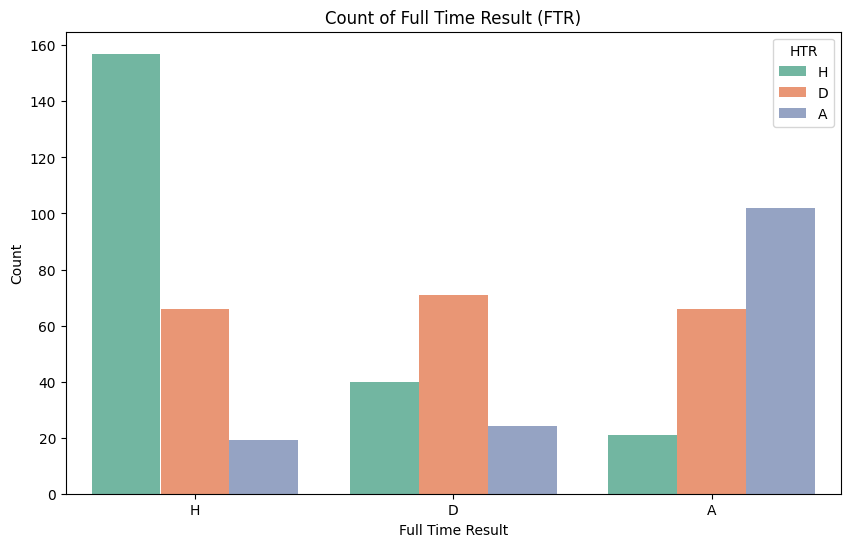

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(x='FTR', data=df, palette='Set2',hue = 'HTR')
plt.title('Count of Full Time Result (FTR)')
plt.xlabel('Full Time Result')
plt.ylabel('Count')
plt.show()

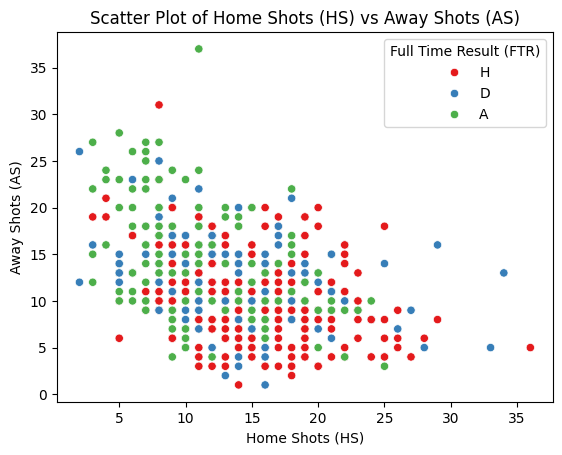

In [14]:
sns.scatterplot(x='HS', y='AS', data=df, hue='FTR', palette='Set1')
plt.title('Scatter Plot of Home Shots (HS) vs Away Shots (AS)')
plt.xlabel('Home Shots (HS)')
plt.ylabel('Away Shots (AS)')
plt.legend(title='Full Time Result (FTR)')
plt.show()

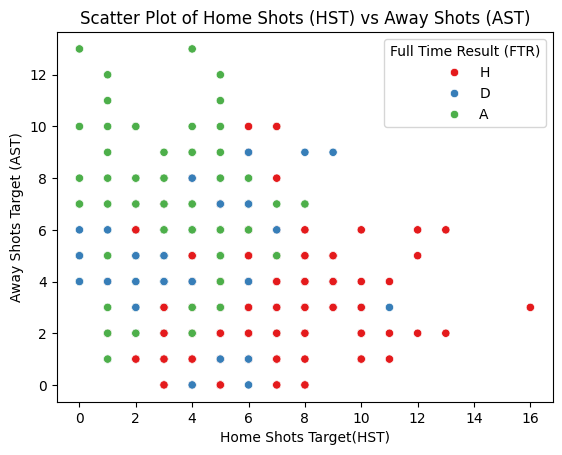

In [15]:
sns.scatterplot(x='HST', y='AST', data=df, hue='FTR', palette='Set1')
plt.title('Scatter Plot of Home Shots (HST) vs Away Shots (AST)')
plt.xlabel('Home Shots Target(HST)')
plt.ylabel('Away Shots Target (AST)')
plt.legend(title='Full Time Result (FTR)')
plt.show()

In [16]:
df.groupby('Season')['FTAG'].mean()

Season
2425    1.421053
2526    1.231183
Name: FTAG, dtype: float64

<Axes: xlabel='FTHG'>

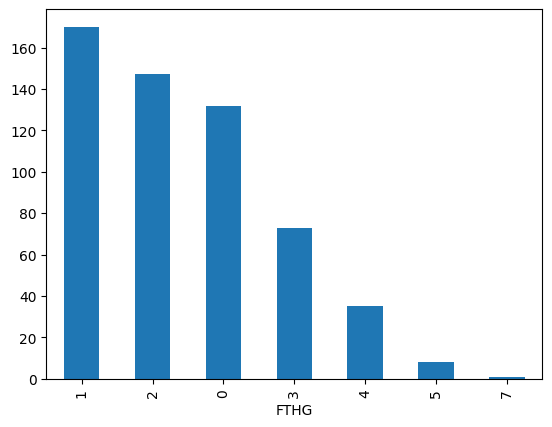

In [17]:
df['FTHG'].value_counts().plot(kind='bar')


In [18]:
df['FTHG'].mean()

np.float64(1.5371024734982333)

/tmp/ipykernel_4627/1553353674.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=means, x='Goals', y='Average_Value', palette='viridis')


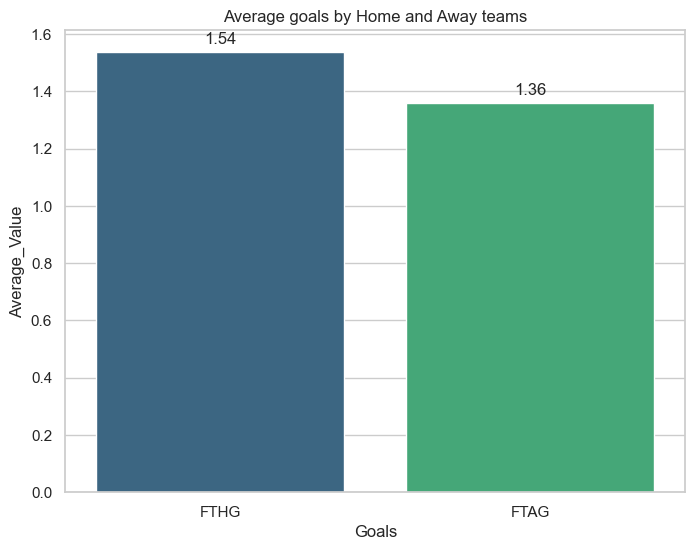

In [19]:
means = df[['FTHG', 'FTAG']].mean().reset_index()
means.columns = ['Goals', 'Average_Value']


# 2. Plotting with Seaborn
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=means, x='Goals', y='Average_Value', palette='viridis')

# Optional: Add the numerical labels on top of the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.title('Average goals by Home and Away teams')
plt.show()

<Axes: xlabel='FTR', ylabel='FTAG'>

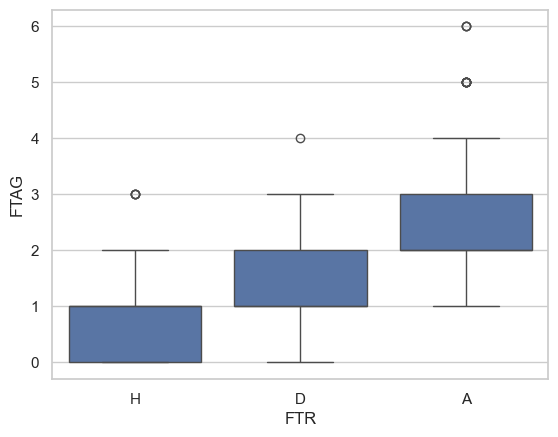

In [20]:
sns.boxplot(data = df , x = 'FTR' , y= 'FTAG')

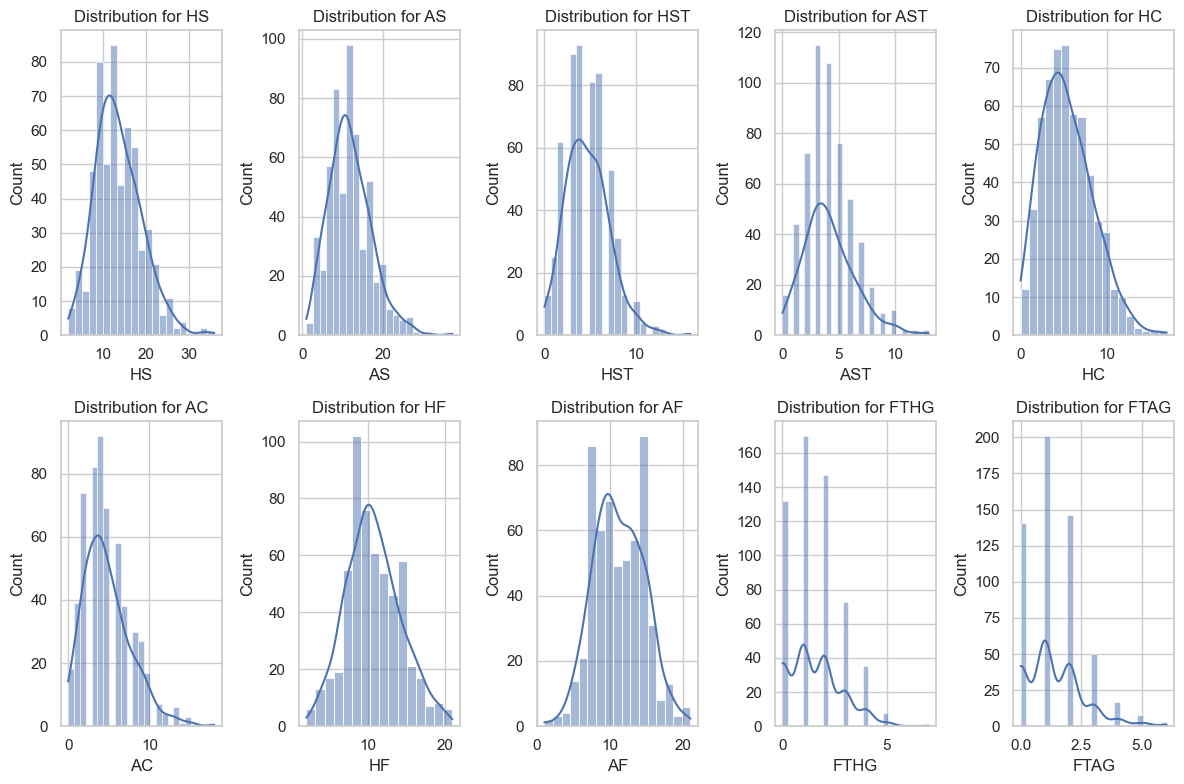

In [21]:
cols = ['HS','AS','HST','AST','HC','AC','HF','AF','FTHG','FTAG']

fig , axes = plt.subplots(2,5,figsize = (12,8))

for ax , col in zip(axes.flatten() , cols):
    sns.histplot(df[col],kde=True,ax = ax)
    ax.set_title(f'Distribution for {col}')
plt.tight_layout()
plt.show()

In [22]:
percentage_of_shots_to_target_H = df['HST'].sum()/df['HS'].sum()
print(percentage_of_shots_to_target_H)

0.34537216828478967


In [23]:
percentage_of_shotsontarget_to_goals_H= df['FTHG'].sum()/df['HS'].sum()
print(percentage_of_shotsontarget_to_goals_H)

0.11262135922330097


In [24]:
percentage_of_shots_to_target_A = df['AST'].sum()/df['AS'].sum()
print(percentage_of_shots_to_target_A)

0.3504581643382905


In [25]:
percentage_of_shotsontarget_to_goals_A= df['FTAG'].sum()/df['AS'].sum()
print(percentage_of_shotsontarget_to_goals_A)

0.11551750037554454


/tmp/ipykernel_4627/3315550960.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = pct , x = 'Shots' , y = 'Count',palette='viridis')


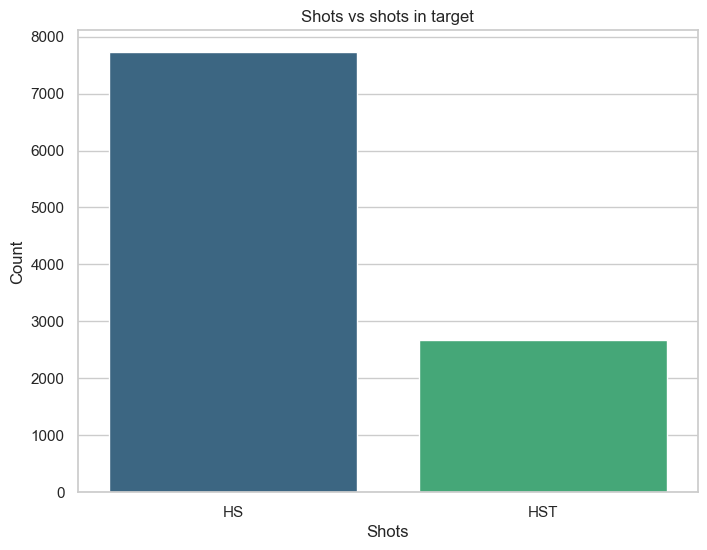

In [26]:
pct = df[['HS','HST']].sum().reset_index()
pct.columns = ['Shots','Count']

plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

sns.barplot(data = pct , x = 'Shots' , y = 'Count',palette='viridis')

plt.title('Shots vs shots in target')
plt.show()

<Axes: xlabel='Season'>

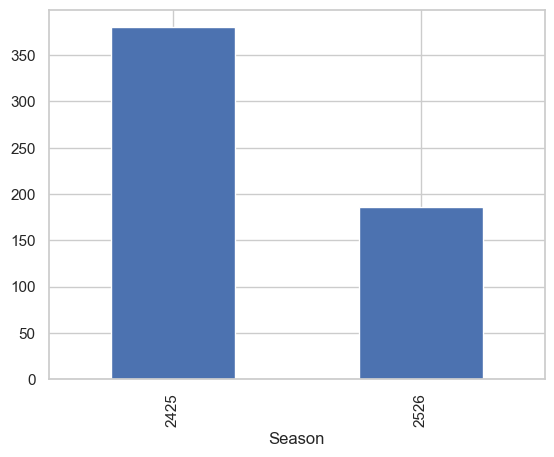

In [27]:
df.groupby('Season')['FTR'].count().plot(kind = 'bar',)

<Axes: xlabel='Season', ylabel='FTHG'>

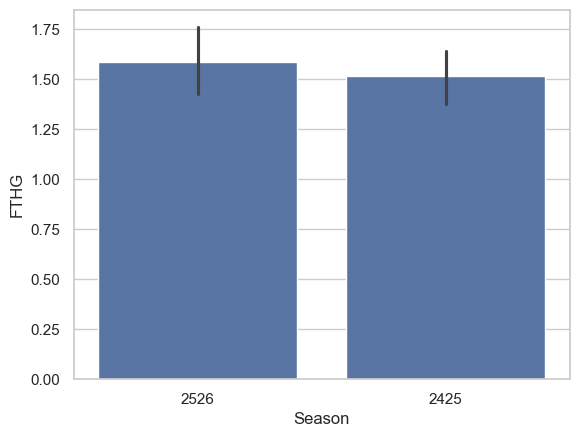

In [28]:
sns.barplot(data = df , x = 'Season',y = 'FTHG')

<Axes: xlabel='Season', ylabel='FTAG'>

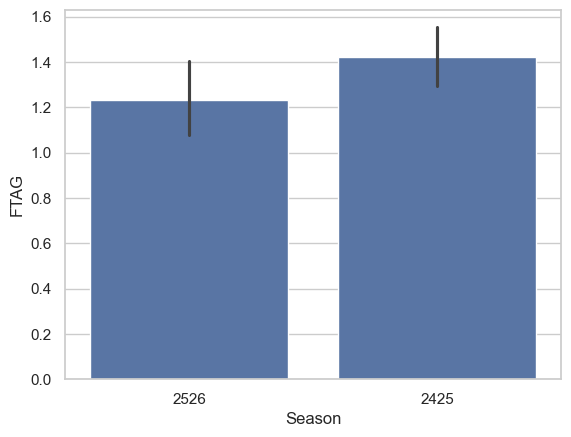

In [29]:
sns.barplot(data = df , x = 'Season',y = 'FTAG')


/tmp/ipykernel_4627/2884743782.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seasonal_home_goals, x='Season', y='FTHG', palette='magma')


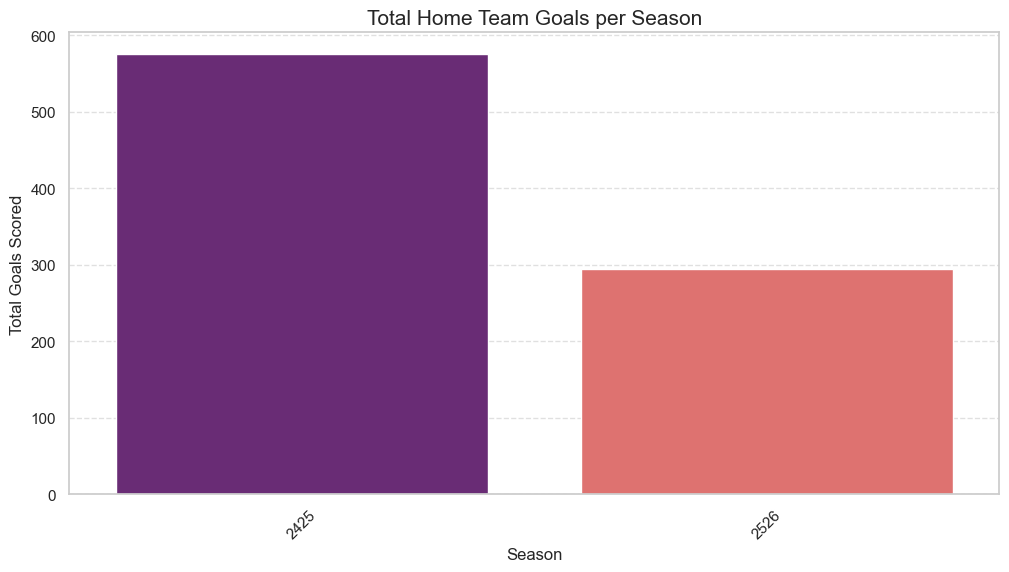

In [30]:
seasonal_home_goals = df.groupby('Season')['FTHG'].sum().reset_index()

# 3. Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(data=seasonal_home_goals, x='Season', y='FTHG', palette='magma')

# Add labels and title
plt.title('Total Home Team Goals per Season', fontsize=15)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Goals Scored', fontsize=12)
plt.xticks(rotation=45) # Helps if you have many seasons
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

/tmp/ipykernel_4627/2608520382.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seasonal_home_goals, x='Season', y='FTAG', palette='magma')


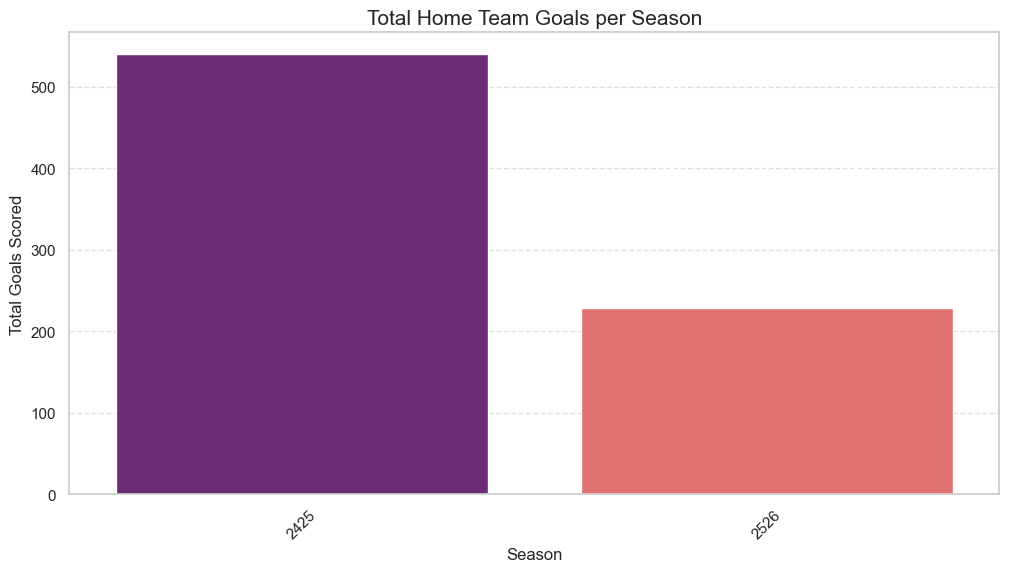

In [31]:
seasonal_home_goals = df.groupby('Season')['FTAG'].sum().reset_index()

# 3. Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(data=seasonal_home_goals, x='Season', y='FTAG', palette='magma')

# Add labels and title
plt.title('Total Home Team Goals per Season', fontsize=15)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Goals Scored', fontsize=12)
plt.xticks(rotation=45) # Helps if you have many seasons
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [32]:
df_copy = df.copy()

In [33]:
df_copy['Total_Goals'] = df_copy['FTHG'] + df_copy['FTAG']


In [34]:
df_copy['Total_Goals'].mean()

np.float64(2.895759717314488)

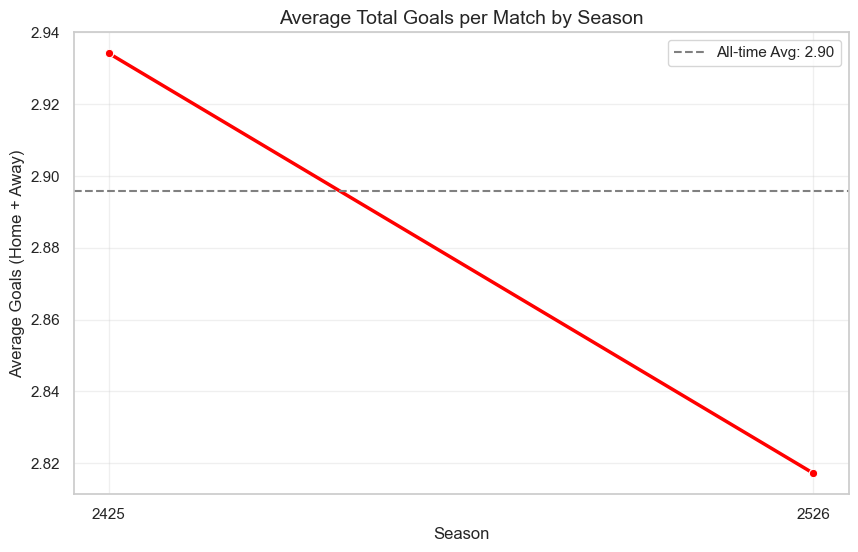

In [35]:
avg_goals_per_season = df_copy.groupby('Season')['Total_Goals'].mean().reset_index()


plt.figure(figsize=(10, 6))
sns.lineplot(data=avg_goals_per_season, x='Season', y='Total_Goals', marker='o', color='red', linewidth=2.5)

overall_mean = df_copy['Total_Goals'].mean()
plt.axhline(overall_mean, color='gray', linestyle='--', label=f'All-time Avg: {overall_mean:.2f}')

plt.title('Average Total Goals per Match by Season', fontsize=14)
plt.ylabel('Average Goals (Home + Away)')
plt.xlabel('Season')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<Axes: xlabel='HomeTeam'>

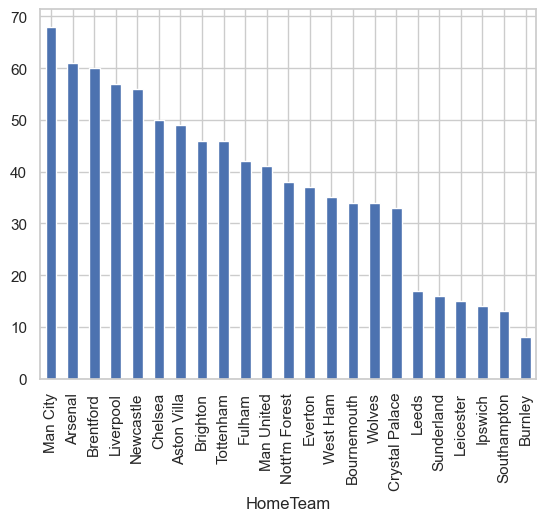

In [36]:
df.groupby('HomeTeam')['FTHG'].sum().sort_values(ascending = False).plot(kind = 'bar')
#Most home goals scored

<Axes: xlabel='AwayTeam'>

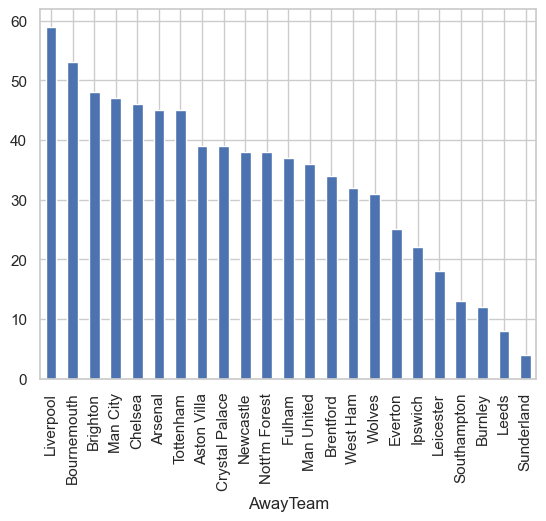

In [37]:
df.groupby('AwayTeam')['FTAG'].sum().sort_values(ascending = False).plot(kind = 'bar')
#Most away goals scored

<Axes: xlabel='HomeTeam'>

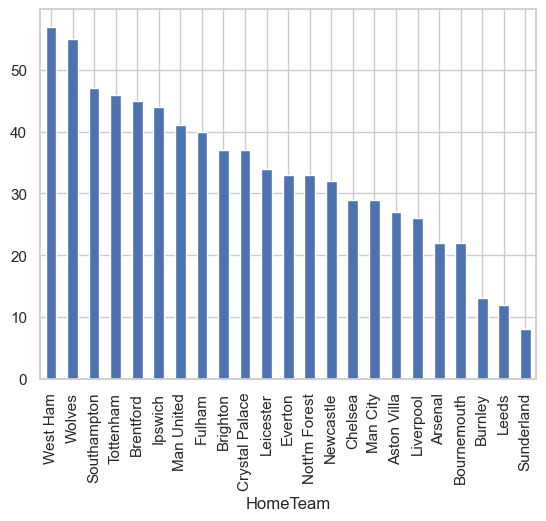

In [38]:
df.groupby('HomeTeam')['FTAG'].sum().sort_values(ascending = False).plot(kind = 'bar')
# Number of goals conceeded by home teams

In [39]:
df[df['FTR']=='H']['HomeTeam'].value_counts()
#Home win stats

HomeTeam
Man City          21
Liverpool         20
Arsenal           20
Aston Villa       18
Newcastle         17
Chelsea           16
Brentford         15
Nott'm Forest     12
Bournemouth       12
Man United        12
Brighton          12
Fulham            12
Everton            9
Tottenham          8
Crystal Palace     8
West Ham           7
Wolves             6
Sunderland         5
Leeds              4
Leicester          4
Burnley            2
Southampton        1
Ipswich            1
Name: count, dtype: int64

In [40]:
df[df['FTR']=='A']['HomeTeam'].value_counts()
#Home lose

HomeTeam
Wolves            18
West Ham          16
Tottenham         15
Southampton       15
Ipswich           14
Leicester         12
Man United        11
Nott'm Forest     11
Fulham            10
Crystal Palace     9
Everton            8
Bournemouth        8
Newcastle          7
Brentford          7
Burnley            6
Chelsea            5
Man City           4
Brighton           4
Liverpool          3
Aston Villa        2
Leeds              2
Arsenal            2
Name: count, dtype: int64

In [41]:
df[df['FTR']=='A']['AwayTeam'].value_counts()
# Away win


AwayTeam
Liverpool         15
Arsenal           14
Man City          13
Aston Villa       13
Chelsea           12
Crystal Palace    12
Nott'm Forest     12
Fulham            11
Tottenham         10
Everton           10
Brighton          10
Newcastle         10
Brentford          9
Bournemouth        8
West Ham           7
Man United         7
Wolves             6
Ipswich            3
Sunderland         2
Leicester          2
Leeds              1
Burnley            1
Southampton        1
Name: count, dtype: int64

In [42]:
df[df['FTR']=='H']['AwayTeam'].value_counts(ascending = True)
# Losing away game

AwayTeam
Sunderland         4
Arsenal            4
Leeds              6
Burnley            7
Liverpool          7
Crystal Palace     8
Man City           9
Chelsea            9
Bournemouth       10
Ipswich           10
Everton           11
Brighton          11
Nott'm Forest     11
West Ham          12
Aston Villa       12
Fulham            12
Man United        12
Newcastle         12
Leicester         13
Tottenham         14
Brentford         15
Southampton       15
Wolves            18
Name: count, dtype: int64

In [43]:
df[df['FTR']=='D']['HomeTeam'].value_counts()
# Home Team Draw


HomeTeam
Brighton          12
Crystal Palace    11
Everton           11
Aston Villa        8
Chelsea            8
Bournemouth        8
Arsenal            7
Fulham             6
Brentford          6
Nott'm Forest      6
Man United         6
West Ham           6
Tottenham          5
Liverpool          5
Sunderland         4
Wolves             4
Newcastle          4
Ipswich            4
Leeds              3
Leicester          3
Southampton        3
Man City           3
Burnley            2
Name: count, dtype: int64

In [44]:
df[df['FTR']=='D']['AwayTeam'].value_counts()
# Away team draw

AwayTeam
Bournemouth       11
Arsenal           10
Man United         9
West Ham           9
Crystal Palace     8
Brighton           8
Everton            8
Newcastle          7
Chelsea            7
Man City           6
Liverpool          6
Ipswich            6
Fulham             5
Nott'm Forest      5
Wolves             5
Aston Villa        4
Tottenham          4
Leicester          4
Brentford          4
Sunderland         3
Southampton        3
Leeds              2
Burnley            1
Name: count, dtype: int64

In [45]:
def get_points(result,side):
    if result == 'D':
        return 1
    elif (result == 'H' and side == 'Home') or (result == 'A' and side == 'Away'):
        return 3
    else:
        return 0

In [ ]:
home_side = df[['Season', 'Date', 'HomeTeam', 'FTHG', 'FTAG', 'FTR']].copy()
home_side.columns = ['Season', 'Date', 'Team', 'GoalsFor', 'GoalsAgainst', 'Result']
home_side['Points'] = home_side['Result'].apply(lambda x: get_points(x, 'Home'))

away_side = df[['Season', 'Date', 'AwayTeam', 'FTAG', 'FTHG', 'FTR']].copy()
away_side.columns = ['Season', 'Date', 'Team', 'GoalsFor', 'GoalsAgainst', 'Result']
away_side['Points'] = away_side['Result'].apply(lambda x: get_points(x, 'Away'))

team_stats = pd.concat([home_side, away_side]).sort_values(['Team', 'Date'])

team_stats['RollingPoints'] = team_stats.groupby('Team')['Points'].transform(lambda x: x.rolling(5, closed='left').mean())
team_stats['RollingGoalsScored'] = team_stats.groupby('Team')['GoalsFor'].transform(lambda x: x.rolling(5, closed='left').mean())
team_stats['RollingGoalsConceeded'] = team_stats.groupby('Team')['GoalsAgainst'].transform(lambda x: x.rolling(5, closed='left').mean())


In [47]:
team_stats.head(10)

,Season,Date,Team,GoalsFor,GoalsAgainst,Result,Points,RollingPoints,RollingGoalsScored,RollingGoalsConceeded
188,2425,2024-08-17,Arsenal,2,0,H,3,NaN,NaN,NaN
202,2425,2024-08-24,Arsenal,2,0,A,3,NaN,NaN,NaN
206,2425,2024-08-31,Arsenal,1,1,D,1,NaN,NaN,NaN
224,2425,2024-09-15,Arsenal,1,0,A,3,NaN,NaN,NaN
235,2425,2024-09-22,Arsenal,2,2,D,1,NaN,NaN,NaN
237,2425,2024-09-28,Arsenal,4,2,H,3,2.2,1.6,0.6
247,2425,2024-10-05,Arsenal,3,1,H,3,2.2,2.0,1.0
262,2425,2024-10-19,Arsenal,0,2,H,0,2.2,2.2,1.2
275,2425,2024-10-27,Arsenal,2,2,D,1,2.0,2.0,1.4
276,2425,2024-11-02,Arsenal,0,1,H,0,1.6,2.2,1.8


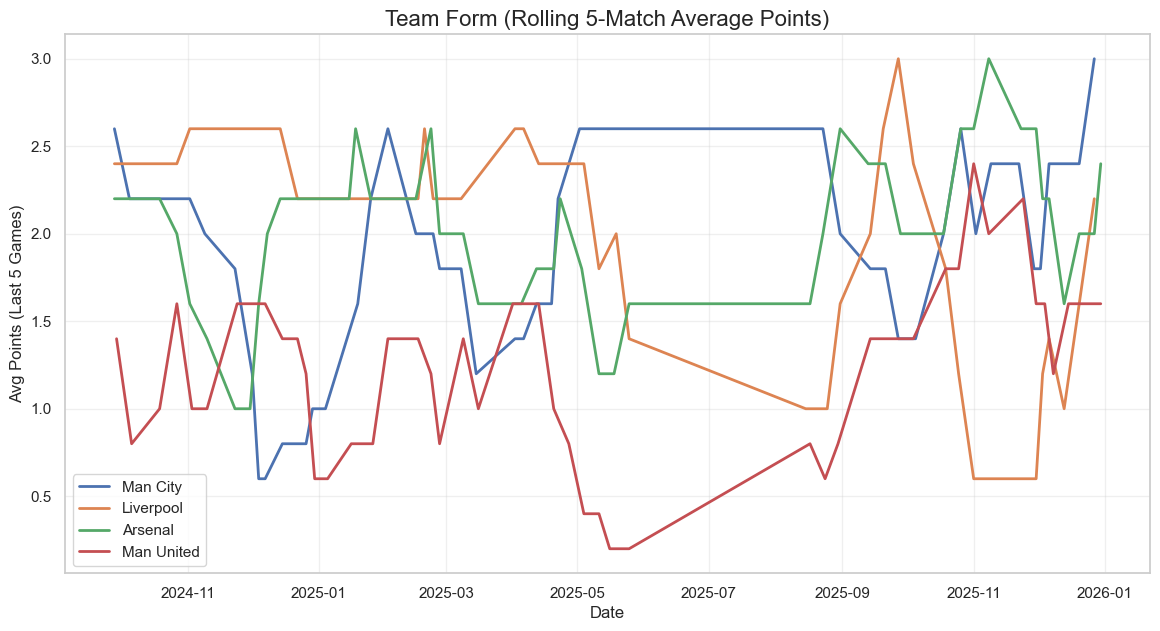

In [48]:
plt.figure(figsize=(14, 7))
top_teams = ['Man City', 'Liverpool', 'Arsenal', 'Man United']

for team in top_teams:
    subset = team_stats[team_stats['Team'] == team]
    plt.plot(subset['Date'], subset['RollingPoints'], label=team, linewidth=2)

plt.title('Team Form (Rolling 5-Match Average Points)', fontsize=16)
plt.ylabel('Avg Points (Last 5 Games)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [49]:
correlation = team_stats[['RollingPoints', 'Points']].corr().iloc[0, 1]
print(f"Correlation between Form and Match Outcome: {correlation:.2f}")

Correlation between Form and Match Outcome: 0.17


In [50]:
correlation = team_stats[['RollingGoalsScored', 'GoalsFor']].corr().iloc[0, 1]
print(f"Correlation between Goal scoring Form and Match goals Outcome: {correlation:.2f}")

Correlation between Goal scoring Form and Match goals Outcome: 0.13


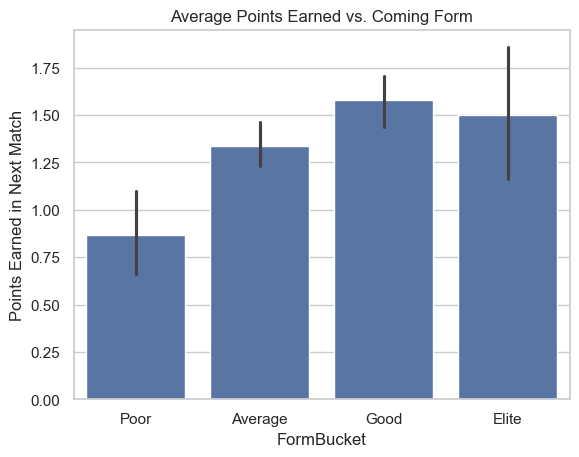

In [51]:
# Create "Form Buckets"
team_stats['FormBucket'] = pd.cut(team_stats['RollingPoints'], bins=[0, 0.5, 1.5, 2.5, 3], labels=['Poor', 'Average', 'Good', 'Elite'],include_lowest=True)
team_stats.dropna(axis = 0,inplace=True)

# Plot Win Rate by Form
sns.barplot(data=team_stats, x='FormBucket', y='Points')
plt.title('Average Points Earned vs. Coming Form')
plt.ylabel('Points Earned in Next Match')
plt.show()

Shots Analysis

In [ ]:
team_stats.groupby('Team')['GoalsFor'].sum().sort_values(ascending = False)
#Most goals

Team
Liverpool         106
Man City          102
Arsenal            98
Brentford          87
Newcastle          87
Brighton           86
Chelsea            85
Bournemouth        82
Tottenham          82
Aston Villa        78
Fulham             72
Man United         72
Nott'm Forest      70
Crystal Palace     68
West Ham           62
Wolves             60
Everton            57
Ipswich            33
Leicester          27
Southampton        24
Leeds              21
Burnley            15
Sunderland         14
Name: GoalsFor, dtype: int64

In [ ]:
home_stats = df.groupby('HomeTeam')[['HS','HST','FTHG']].mean()
away_stats = df.groupby('AwayTeam')[['HS','HST','FTHG']].mean()

home_stats.columns = ['Shots', 'SoT', 'Goals']
away_stats.columns = ['Shots', 'SoT', 'Goals']

team_stats = (home_stats + away_stats) / 2

team_stats['Accuracy %'] = (team_stats['SoT'] / team_stats['Shots']) * 100
team_stats['Conversion %'] = (team_stats['Goals'] / team_stats['Shots']) * 100

team_stats.sort_values(by = 'Conversion %' , ascending = False)
#best attack

,Shots,SoT,Goals,Accuracy %,Conversion %
HomeTeam,,,,,
Leeds,13.666667,4.888889,2.055556,35.772358,15.040650
Man City,13.517857,5.089286,1.785714,37.648613,13.210040
Burnley,13.361111,4.288889,1.733333,32.099792,12.972973
Liverpool,13.857143,4.892857,1.750000,35.309278,12.628866
Wolves,12.290640,4.292488,1.538177,34.924850,12.515030
Newcastle,13.432266,4.746305,1.672414,35.335106,12.450720
Brentford,14.250000,5.357143,1.750000,37.593985,12.280702
Brighton,13.671798,4.674877,1.666256,34.193577,12.187542
Leicester,13.500000,4.552632,1.605263,33.723197,11.890838


In [57]:
correlation = df[['HS','HST','FTHG']].corr()
correlation

,HS,HST,FTHG
HS,1.000000,0.672676,0.306958
HST,0.672676,1.000000,0.589206
FTHG,0.306958,0.589206,1.000000


In [59]:
correlation = df[['AS','AST','FTAG']].corr()
correlation

,AS,AST,FTAG
AS,1.000000,0.67838,0.315361
AST,0.678380,1.00000,0.580800
FTAG,0.315361,0.58080,1.000000


Corner analysis


In [60]:
home_stats = df.groupby('HomeTeam')[['HC']].mean()
away_stats = df.groupby('AwayTeam')[['AC']].mean()

home_stats.columns = ['Corners']
away_stats.columns = ['Corners']

team_stats = (home_stats + away_stats) / 2


most_corners = team_stats.sort_values(by = 'Corners' , ascending = False)
most_corners

,Corners
HomeTeam,
Man City,6.357143
Arsenal,6.323276
Liverpool,6.160714
Tottenham,6.089286
Chelsea,6.075739
Newcastle,5.941502
Bournemouth,5.930419
Aston Villa,5.771552
Fulham,5.214286


In [61]:
correlation = df[['HC','FTHG']].corr()
correlation

,HC,FTHG
HC,1.000000,0.069011
FTHG,0.069011,1.000000


Discipline analysis

In [65]:
df_discipline = df.copy()

df_discipline['H_Discipline_Score'] = (df_discipline['HF'] * 1) + (df_discipline['HY'] * 3) + (df_discipline['HR'] * 10)
df_discipline['A_Discipline_Score'] = (df_discipline['AF'] * 1) + (df_discipline['AY'] * 3) + (df_discipline['AR'] * 10)


# df_discipline[['H_Discipline_Score','A_Discipline_Score']] = df_discipline[['H_Discipline_Score','A_Discipline_Score']].fillna(0)

In [67]:

home_discipline = df_discipline.groupby('HomeTeam')[['HF', 'HY', 'HR', 'H_Discipline_Score']].mean()
away_discipline = df_discipline.groupby('AwayTeam')[['AF', 'AY', 'AR', 'A_Discipline_Score']].mean()

home_discipline.columns = ['Fouls', 'Yellows', 'Reds', 'Score']
away_discipline.columns = ['Fouls', 'Yellows', 'Reds', 'Score']

total_discipline = (home_discipline + away_discipline) / 2


aggressive_teams = total_discipline.sort_values(by='Score', ascending=False)
print(aggressive_teams)

                    Fouls   Yellows      Reds      Score
HomeTeam                                                
Bournemouth     13.197660  2.485837  0.070197  21.357143
Chelsea         11.530788  2.442118  0.105296  19.910099
Southampton     12.078947  2.342105  0.078947  19.894737
Wolves          13.150862  1.995074  0.070197  19.838054
Ipswich         11.315789  2.210526  0.131579  19.263158
Brighton        11.803571  2.116995  0.051724  18.671798
Tottenham       11.535714  2.071429  0.053571  18.285714
Leicester       11.052632  2.289474  0.000000  17.921053
West Ham        11.329433  1.894089  0.087438  17.886084
Fulham          11.303571  2.071429  0.035714  17.875000
Everton         10.943350  2.055419  0.052956  17.639163
Man United      10.771552  1.913177  0.069581  17.206897
Crystal Palace  10.642857  1.928571  0.071429  17.142857
Sunderland       9.944444  2.000000  0.111111  17.055556
Nott'm Forest   10.360222  2.062808  0.035714  16.905788
Aston Villa     10.519704  1.80

Betting Odds analysis

In [69]:
df_bet = df.copy()
df_bet['P_H'] = 1/df['B365H']
df_bet['P_A'] = 1/df['B365A']
df_bet['P_D'] = 1/df['B365D']


df_bet['HomeWin'] = (df_bet['FTR'] == 'H').astype(int)

df_bet['Prob_Bin'] = pd.cut(df_bet['P_H'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0])

calibration = df_bet.groupby('Prob_Bin', observed=True).agg({
    'P_H': 'mean',
    'HomeWin': 'mean'
})

print(calibration)


                 P_H   HomeWin
Prob_Bin                      
(0.0, 0.2]  0.156801  0.075472
(0.2, 0.4]  0.313988  0.284916
(0.4, 0.6]  0.495261  0.488764
(0.6, 0.8]  0.694057  0.597015
(0.8, 1.0]  0.864095  0.909091


In [72]:
print(df_bet[['HomeWin','P_H']].corr())

         HomeWin      P_H
HomeWin  1.00000  0.38495
P_H      0.38495  1.00000


Correlation Analysis

In [74]:
print(df[['FTHG','HS','HC','HF','HR','HY']].corr())
#which feature matter most

          FTHG        HS        HC        HF        HR        HY
FTHG  1.000000  0.306958  0.069011 -0.092246 -0.111208 -0.069332
HS    0.306958  1.000000  0.527852 -0.051614 -0.136809 -0.081536
HC    0.069011  0.527852  1.000000 -0.065272 -0.107610 -0.034003
HF   -0.092246 -0.051614 -0.065272  1.000000  0.054034  0.293911
HR   -0.111208 -0.136809 -0.107610  0.054034  1.000000 -0.000018
HY   -0.069332 -0.081536 -0.034003  0.293911 -0.000018  1.000000


Draw Analysis

In [78]:

home_draws = df.groupby('HomeTeam')['FTR'].apply(lambda x: (x == 'D').sum())
away_draws = df.groupby('AwayTeam')['FTR'].apply(lambda x: (x == 'D').sum())
total_games = df.groupby('HomeTeam')['FTR'].count() + df.groupby('AwayTeam')['FTR'].count()

draw_rate = ((home_draws + away_draws) / total_games).sort_values(ascending=False)
print(draw_rate)

HomeTeam
Sunderland        0.388889
Brighton          0.350877
Crystal Palace    0.339286
Bournemouth       0.333333
Everton           0.333333
Arsenal           0.298246
Leeds             0.277778
Man United        0.263158
West Ham          0.263158
Ipswich           0.263158
Chelsea           0.263158
Aston Villa       0.210526
Fulham            0.196429
Liverpool         0.196429
Newcastle         0.192982
Nott'm Forest     0.192982
Leicester         0.184211
Brentford         0.178571
Man City          0.160714
Tottenham         0.160714
Burnley           0.157895
Southampton       0.157895
Wolves            0.157895
Name: FTR, dtype: float64


In [ ]:

home_draws = df.groupby('HomeTeam')['FTR'].apply(lambda x: (x == 'A').sum())
away_draws = df.groupby('AwayTeam')['FTR'].apply(lambda x: (x == 'H').sum())
total_games = df.groupby('HomeTeam')['FTR'].count() + df.groupby('AwayTeam')['FTR'].count()

draw_rate = ((home_draws + away_draws) / total_games).sort_values(ascending=False)
print(draw_rate)
#lose away games

HomeTeam
Southampton       0.789474
Burnley           0.684211
Leicester         0.657895
Ipswich           0.631579
Wolves            0.631579
Tottenham         0.517857
West Ham          0.491228
Leeds             0.444444
Man United        0.403509
Fulham            0.392857
Brentford         0.392857
Nott'm Forest     0.385965
Newcastle         0.333333
Everton           0.333333
Bournemouth       0.315789
Crystal Palace    0.303571
Brighton          0.263158
Aston Villa       0.245614
Chelsea           0.245614
Man City          0.232143
Sunderland        0.222222
Liverpool         0.178571
Arsenal           0.105263
Name: FTR, dtype: float64


In [80]:
# Create bins for Draw Odds
df['Draw_Odds_Bin'] = pd.cut(df['B365D'], bins=[2, 3, 3.5, 4, 5, 10])

# Calculate actual Draw frequency per odds bin
draw_analysis = df.groupby('Draw_Odds_Bin', observed=True)['FTR'].apply(lambda x: (x == 'D').mean())
print(draw_analysis)

Draw_Odds_Bin
(2.0, 3.0]     0.000000
(3.0, 3.5]     0.241611
(3.5, 4.0]     0.260000
(4.0, 5.0]     0.251799
(5.0, 10.0]    0.162162
Name: FTR, dtype: float64


In [81]:
# Create Total Goals Column
df['Total_Goals'] = df['FTHG'] + df['FTAG']

# Correlation between low goal counts and draws
draw_by_goals = df.groupby('Total_Goals')['FTR'].apply(lambda x: (x == 'D').mean())
print(draw_by_goals)

Total_Goals
0    1.000000
1    0.000000
2    0.456522
3    0.000000
4    0.428571
5    0.000000
6    0.150000
7    0.000000
8    0.333333
9    0.000000
Name: FTR, dtype: float64
